In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [ ]:
#PART 1

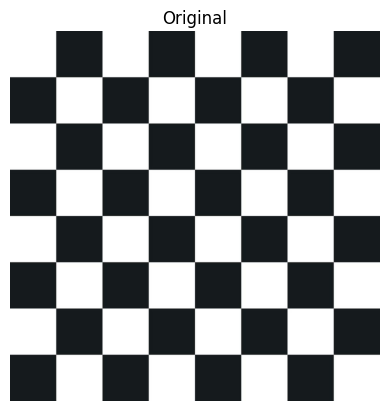

In [2]:
img = cv2.cvtColor(cv2.imread("/content/chss.jpg"), cv2.COLOR_BGR2RGB)
img_square=cv2.cvtColor(cv2.imread("/content/chss.jpg"), cv2.COLOR_BGR2RGB)
plt.imshow(img);
plt.title("Original")
plt.axis("off")
plt.show()

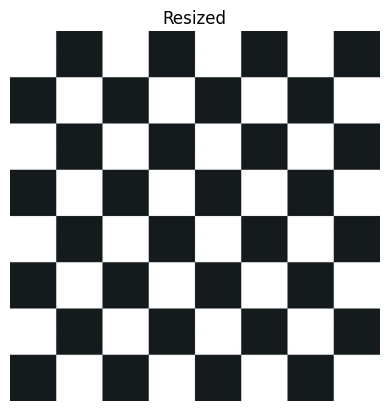

In [3]:
img_resize = cv2.resize(img, (256,256))
plt.imshow(img_resize)
plt.title("Resized")
plt.axis("off")
plt.show()

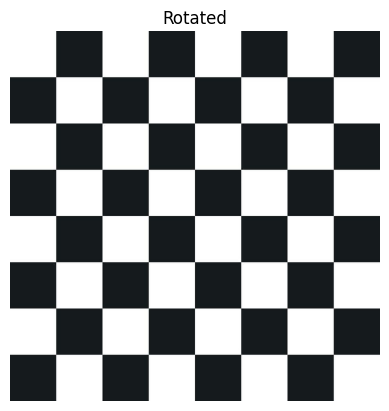

In [4]:
img_rotate = cv2.rotate(img_resize, cv2.ROTATE_180)
plt.imshow(img_rotate)
plt.title("Rotated")
plt.axis("off")
plt.show()

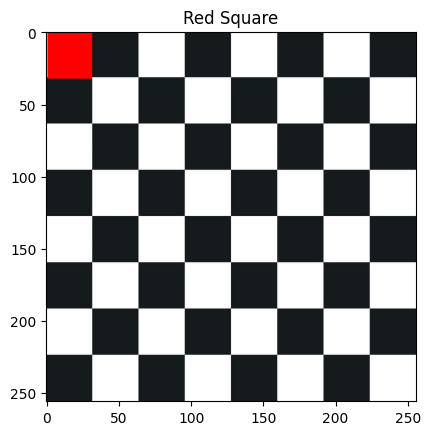

In [5]:
img_square = img_rotate.copy()
img_square[1:33, 1:32] = [255,0,0]
plt.imshow(img_square)
plt.title("Red Square")
#plt.axis("off")
plt.show()

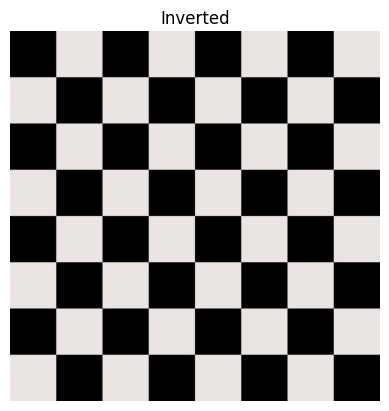

In [6]:
img_invert = 255 - img
plt.imshow(img_invert)
plt.title("Inverted")
plt.axis("off")
plt.show()


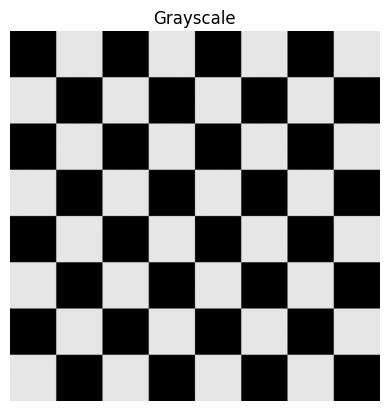

In [7]:
gray = cv2.cvtColor(img_invert, cv2.COLOR_RGB2GRAY)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")
plt.show()

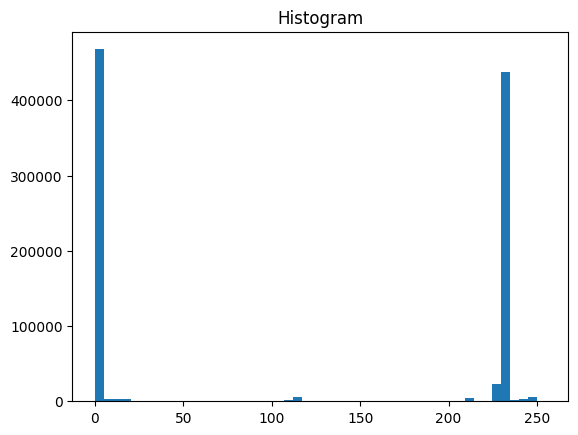

In [8]:
plt.hist(gray.flatten(), bins=50)
plt.title("Histogram")
plt.show()

In [ ]:
#PART 2


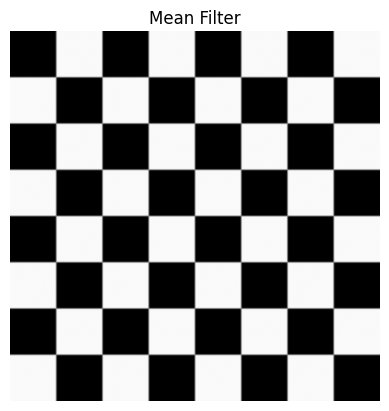

In [9]:
mean = cv2.blur(gray, (5,5))
plt.imshow(mean, cmap="gray")
plt.title("Mean Filter")
plt.axis("off")
plt.show()

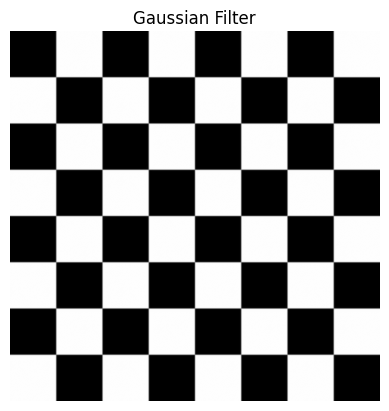

In [10]:
gauss = cv2.GaussianBlur(gray, (5,5), 0)
plt.imshow(gauss, cmap="gray")
plt.title("Gaussian Filter")
plt.axis("off")
plt.show()


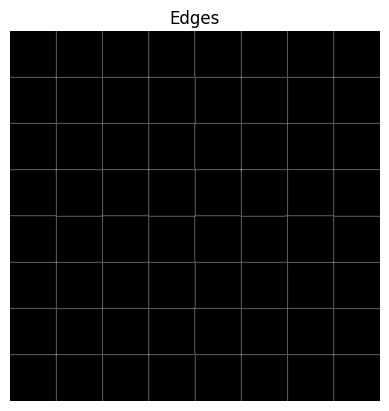

In [11]:
edges = cv2.Canny(gray, 100, 200)
plt.imshow(edges, cmap="gray")
plt.title("Edges")
plt.axis("off")
plt.show()

In [ ]:
#PART3

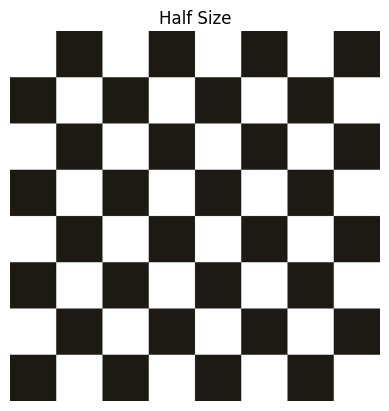

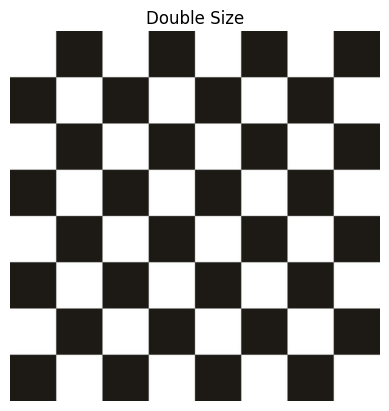

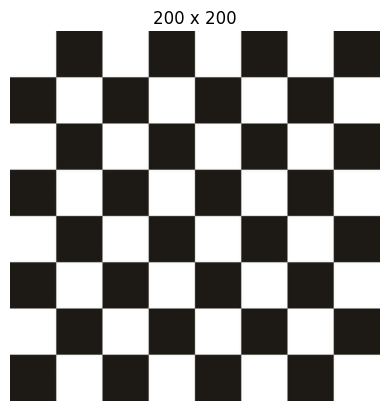

In [12]:
width, height = img.shape[:2]
half = cv2.resize(img, (width // 2, height // 2))
double = cv2.resize(img, (width * 2, height * 2))
fixed = cv2.resize(img, (200, 200))

plt.imshow(cv2.cvtColor(half, cv2.COLOR_BGR2RGB))
plt.title('Half Size')
plt.axis('off')
plt.show()

plt.imshow(cv2.cvtColor(double, cv2.COLOR_BGR2RGB))
plt.title('Double Size')
plt.axis('off')
plt.show()

plt.imshow(cv2.cvtColor(fixed, cv2.COLOR_BGR2RGB))
plt.title('200 x 200')
plt.axis('off')
plt.show()

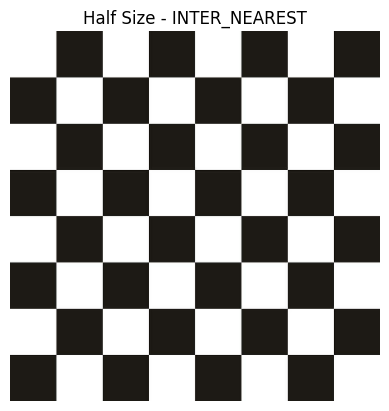

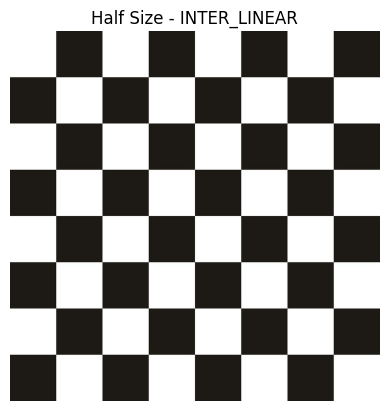

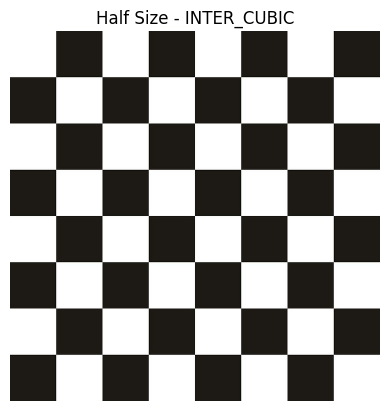

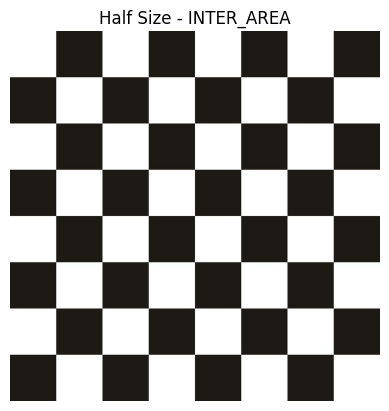

In [13]:
methods = {
    "INTER_NEAREST": cv2.INTER_NEAREST,
    "INTER_LINEAR": cv2.INTER_LINEAR,
    "INTER_CUBIC": cv2.INTER_CUBIC,
    "INTER_AREA": cv2.INTER_AREA
}

for name, method in methods.items():
    resized = cv2.resize(img, (width // 2, height // 2), interpolation=method)
    plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
    plt.title(f"Half Size - {name}")
    plt.axis('off')
    plt.show()

Original corners: 1521


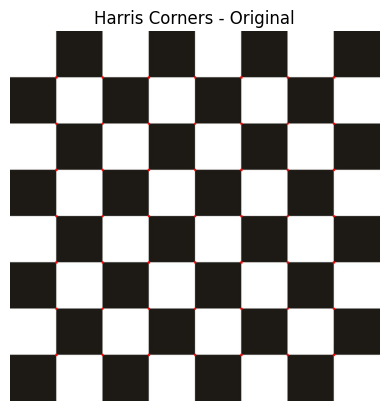

Half corners: 1555


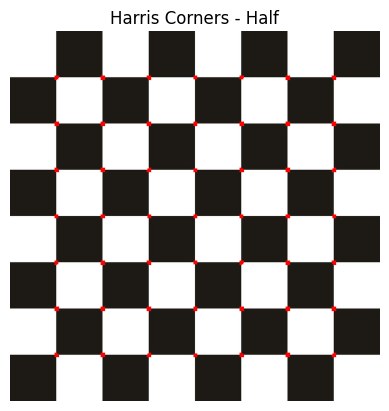

Double corners: 2625


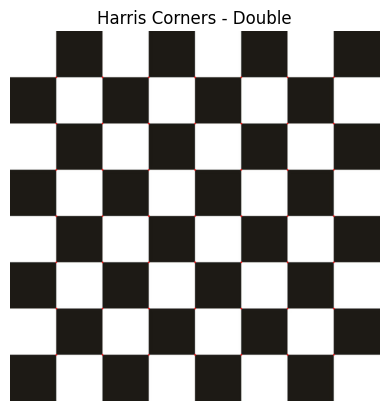

200x200 corners: 1225


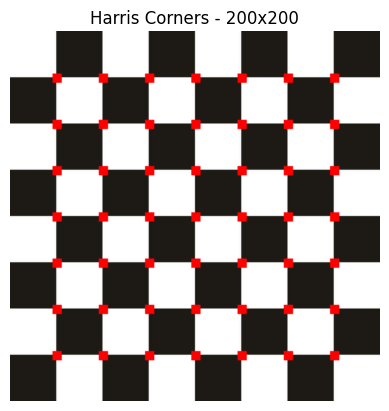

In [14]:
images = {
    "Original": img,
    "Half": half,
    "Double": double,
    "200x200": fixed
}

for name, im in images.items():
    gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    gray = np.float32(gray)

    dst = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)
    dst = cv2.dilate(dst, None)

    corners_count = np.sum(dst > 0.01 * dst.max())
    print(name, "corners:", corners_count)

    im_corners = im.copy()
    im_corners[dst > 0.01 * dst.max()] = [0, 0, 255]

    plt.imshow(cv2.cvtColor(im_corners, cv2.COLOR_BGR2RGB))
    plt.title(f"Harris Corners - {name}")
    plt.axis('off')
    plt.show()

In [ ]:
#PART4

Otsu threshold value: 172.0


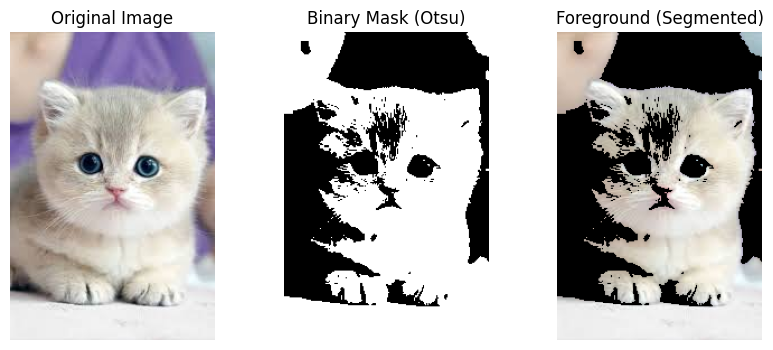

In [16]:


image = cv2.imread("/content/cat.jfif")
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
threshold_value, mask = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)  #255->white , 0->black
print("Otsu threshold value:", threshold_value)
foreground = cv2.bitwise_and(image, image, mask=mask)
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask (Otsu)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(foreground, cv2.COLOR_BGR2RGB))
plt.title("Foreground (Segmented)")
plt.axis('off')

plt.show()


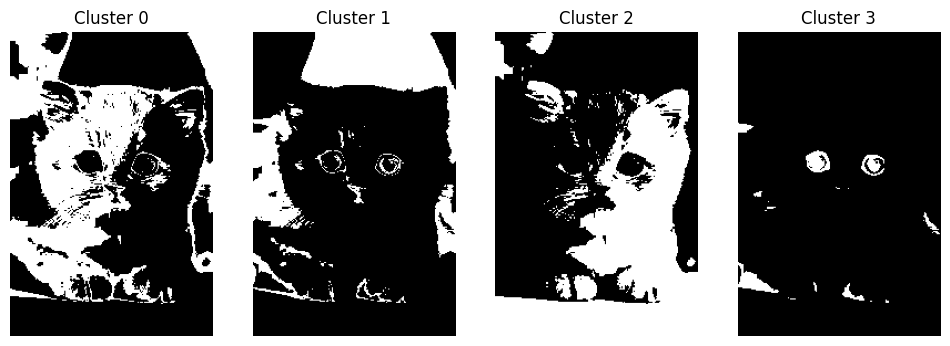

In [17]:
lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)  #separates brightness from color
Z = lab.reshape(-1, 3).astype(np.float32)
K = 4
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
_, labels, _ = cv2.kmeans(Z, K, None, criteria, 5, cv2.KMEANS_PP_CENTERS)

seg = labels.reshape(image.shape[:2])

plt.figure(figsize=(12,4))
for k in range(K):
    mask = np.uint8(seg == k) * 255
    plt.subplot(1, K, k+1)
    plt.imshow(mask, cmap="gray")
    plt.title(f"Cluster {k}")
    plt.axis("off")
plt.show()

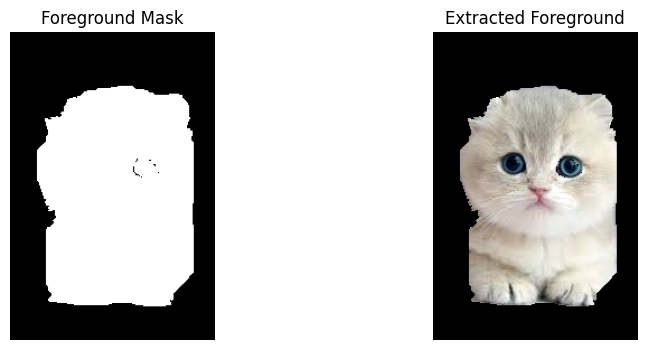

In [18]:

image = cv2.imread("/content/cat.jfif")

height, width = image.shape[:2]

x = int(0.10 * width)
y = int(0.10 * height)
rect_width = int(0.80 * width)
rect_height = int(0.80 * height)
rectangle = (x, y, rect_width, rect_height)

mask = np.zeros((height, width), np.uint8)
background = np.zeros((1, 65), np.float64)
foreground = np.zeros((1, 65), np.float64)

cv2.grabCut(image, mask, rectangle, background, foreground, 5, cv2.GC_INIT_WITH_RECT)

binary_mask = np.where((mask == 1) | (mask == 3), 255, 0).astype('uint8')

result = cv2.bitwise_and(image, image, mask=binary_mask)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(binary_mask, cmap='gray')
plt.title("Foreground Mask")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Extracted Foreground")
plt.axis('off')

plt.show()


In [ ]:
#PART 5

In [19]:
X = cv2.resize(img, (32,32)).reshape(1,32,32,3)/255
y = np.array([0])

In [26]:
cnn = Sequential([
    Conv2D(32,3,activation='relu',input_shape=(32,32,3)),
    MaxPooling2D(),
    Conv2D(64,3,activation='relu'),
    Flatten(),
    Dense(64,activation='relu'),
    Dense(2,activation='softmax')
])
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.fit(X, y, epochs=10)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.4487
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 1.0000 - loss: 0.0012
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 1.0000 - loss: 1.2278e-05
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 2.3842e-07
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 0.0000e+00


In [21]:
mlp = Sequential([
    Flatten(input_shape=(32,32,3)),
    Dense(64,activation='relu'),
    Dense(2,activation='softmax')
])
mlp.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
mlp.fit(X, y, epochs=10)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.0000e+00 - loss: 1.5062
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 1.0000 - loss: 0.0163
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 1.0000 - loss: 0.0017
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 1.0000 - loss: 3.2622e-04
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 1.0000 - loss: 8.0821e-05
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 1.0000 - loss: 2.4557e-05
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 1.0000 - loss: 8.7022e-06
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 1.0000 - loss: 3.4571e-06
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 1.0000 - loss: 1.5497e-06
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 1.0000 - loss: 7.1526e-07


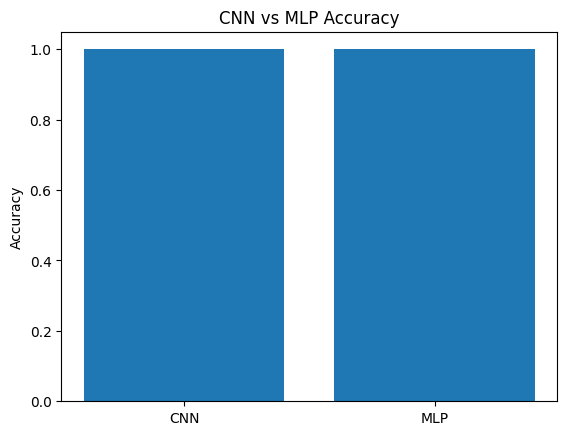

In [31]:
cnn_acc = 1.0
mlp_acc = 1.0
models = ['CNN', 'MLP']
acc = [cnn_acc, mlp_acc]
plt.bar(models, acc)
plt.ylabel("Accuracy")
plt.title("CNN vs MLP Accuracy")
plt.show()